The notebook presents simple examples to get started with training a fully-connected neural network.

* Neurons, layers and activation functions (Part 1)
* Learning a simple function (Part 2)  
* Learning a function that converts from cartesian to polar coordinates (Part 3)
* Saving and reusing a model (Part 4)

It takes inpiration from [Pytorch Hello World](https://colab.research.google.com/drive/1ac0K9_aa46c77XEeYtaMAfSOfmH1Bl9L) (Elvis Saravia) and [Hello-ML-World](https://colab.research.google.com/github/lmoroney/mlday-tokyo/blob/master/Lab1-Hello-ML-World.ipynb) (Laurence Moroney).

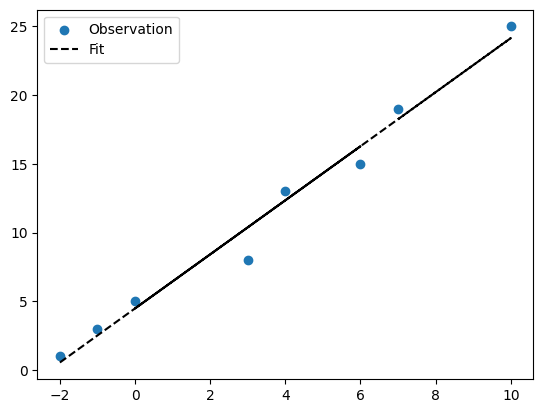

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
x = [-2, -1, 3, 4, 6, 0, 10, 7]
y = [1, 3, 8, 13, 15, 5, 25, 19]

plt.scatter(x, y, label = "Observation")

coef = np.polyfit(x, y, 1)
poly1d_fn = np.poly1d(coef)
plt.plot(x, poly1d_fn(x), '--k', label = "Fit")
plt.legend()
plt.show()

# Part 1: Neurons, Layers and Activations functions

In [7]:
import torch
import torch.nn as nn
import numpy as np

## Input features as tensors

In [8]:
input_features = torch.tensor([[1.5, 8, 2]], dtype=torch.float) # one data point, 3 input values
input_features, input_features.shape

(tensor([[1.5000, 8.0000, 2.0000]]), torch.Size([1, 3]))

## A simple neural network


In [20]:
single_neuron = nn.Linear(3, 1, bias=True) # 3 features, 1 neuron
single_neuron, single_neuron.weight, single_neuron.weight.shape, single_neuron.bias

(Linear(in_features=3, out_features=1, bias=True),
 Parameter containing:
 tensor([[ 0.0119, -0.1100, -0.0125]], requires_grad=True),
 torch.Size([1, 3]),
 Parameter containing:
 tensor([0.4353], requires_grad=True))

In [21]:
single_neuron(input_features)

tensor([[-0.4523]], grad_fn=<AddmmBackward0>)

In [23]:
i_features = [1.5000, 8.0000, 2.0000]
w_i = [ 0.0119, -0.1100, -0.0125]
w_0 = 0.4353
(i_features[0] *w_i[0] + i_features[1]*w_i[1] + i_features[2]* w_i[2]) + w_0

-0.45185

## Activation function

In [22]:
relu = nn.ReLU()
sigmoid = nn.Sigmoid()
tanh = nn.Tanh()
elu = nn.ELU()

values_tens = torch.tensor([3.0])

print("heaviside: ", torch.heaviside(single_neuron(input_features), values_tens)) # https://docs.pytorch.org/docs/stable/generated/torch.heaviside.html
print("relu: ", relu(single_neuron(input_features))) # https://docs.pytorch.org/docs/2.11/generated/torch.nn.ReLU.html
print("tanh: ", tanh(single_neuron(input_features))) # https://docs.pytorch.org/docs/2.11/generated/torch.nn.Tanh.html
print("sigmoid: ", sigmoid(single_neuron(input_features))) # https://docs.pytorch.org/docs/2.11/generated/torch.nn.Sigmoid.html
print("elu: ", elu(single_neuron(input_features))) # https://docs.pytorch.org/docs/2.11/generated/torch.nn.ELU.html

heaviside:  tensor([[0.]], grad_fn=<NotImplemented>)
relu:  tensor([[0.]], grad_fn=<ReluBackward0>)
tanh:  tensor([[-0.4238]], grad_fn=<TanhBackward0>)
sigmoid:  tensor([[0.3888]], grad_fn=<SigmoidBackward0>)
elu:  tensor([[-0.3638]], grad_fn=<EluBackward0>)


## convlayer (image processing)

In [24]:
conv_layer = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=2, stride=1, padding=1)
conv_layer, conv_layer.weight, conv_layer.weight.shape, conv_layer.bias

(Conv2d(1, 1, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1)),
 Parameter containing:
 tensor([[[[-0.2791, -0.3924],
           [ 0.3795, -0.3619]]]], requires_grad=True),
 torch.Size([1, 1, 2, 2]),
 Parameter containing:
 tensor([-0.3770], requires_grad=True))

## linear layer*
**image generated using chatpgt*

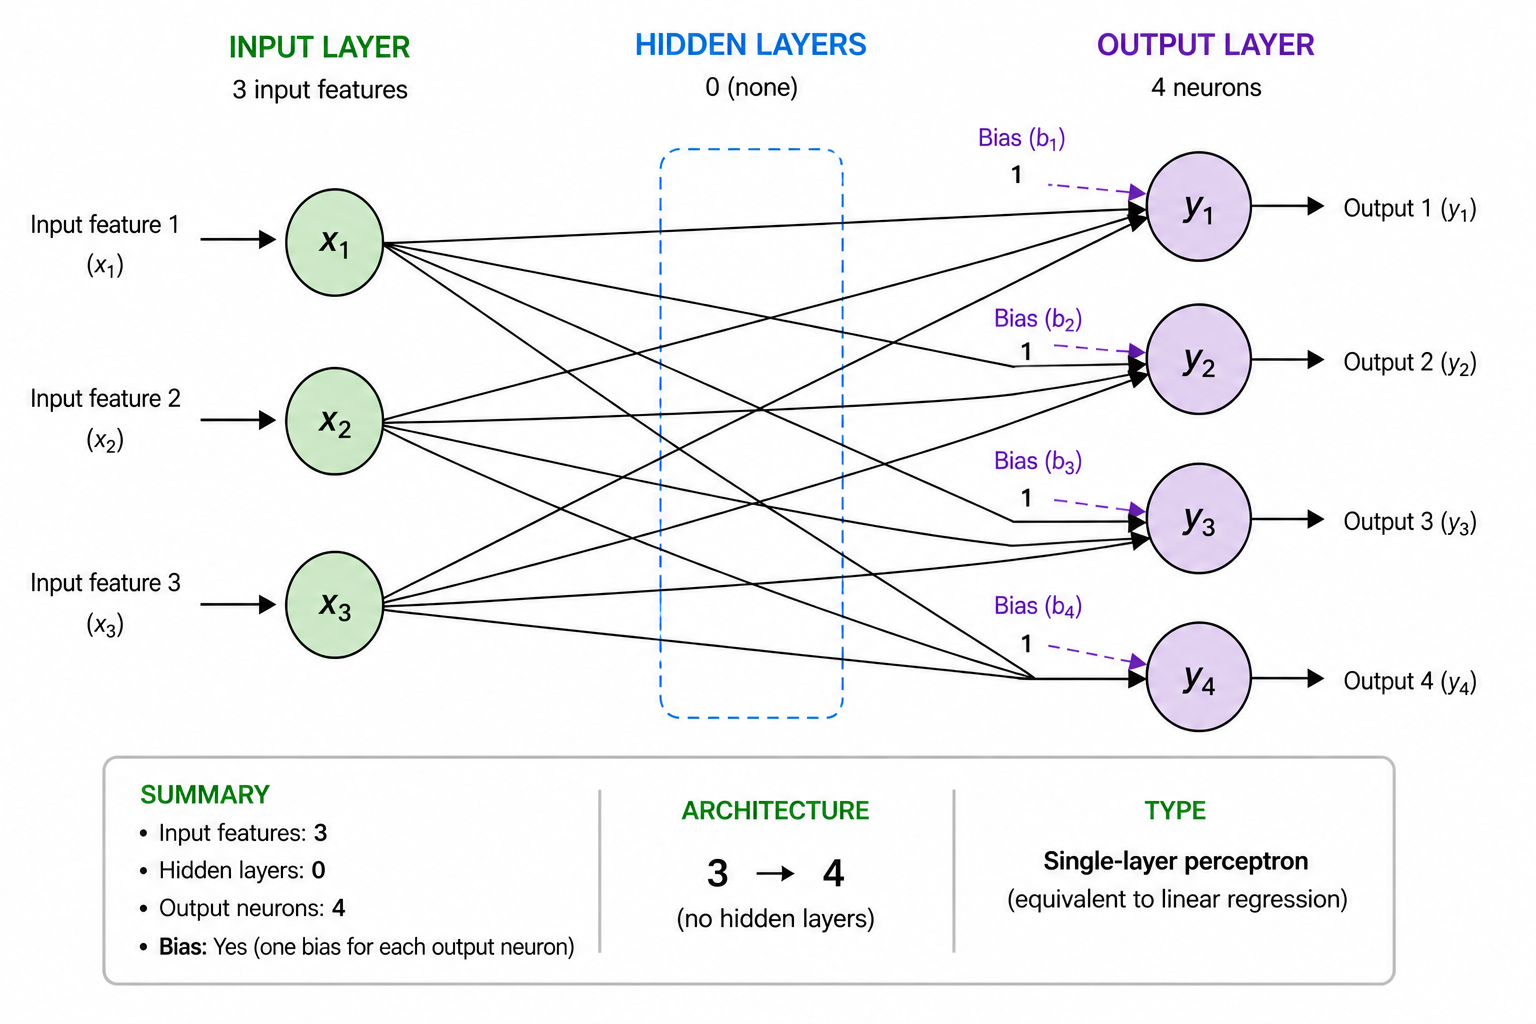

In [25]:
linear_layer = nn.Linear(3, 4, bias=True) # 3 features, 4 neurons
linear_layer, linear_layer.weight, linear_layer.weight.shape, linear_layer.bias

(Linear(in_features=3, out_features=4, bias=True),
 Parameter containing:
 tensor([[-0.4512,  0.4611, -0.4275],
         [ 0.1407,  0.2158,  0.3072],
         [ 0.0914,  0.1129,  0.1705],
         [-0.5087,  0.3962,  0.3087]], requires_grad=True),
 torch.Size([4, 3]),
 Parameter containing:
 tensor([ 0.0597, -0.5278, -0.0735, -0.2494], requires_grad=True))

In [26]:
linear_layer(input_features)

tensor([[2.2165, 2.0242, 1.3078, 2.7743]], grad_fn=<AddmmBackward0>)

In [27]:
i_features = [1.5000, 8.0000, 2.0000]
w_n_1 = [-0.4512,  0.4611, -0.4275]
w_n_2 = [ 0.1407,  0.2158,  0.3072]
w_n_3 = [ 0.0914,  0.1129,  0.1705]
w_n_4 = [-0.5087,  0.3962,  0.3087]
bias_values = [ 0.0597, -0.5278, -0.0735, -0.2494]

output1 = (i_features[0] *w_n_1[0] + i_features[1]*w_n_1[1] + i_features[2]* w_n_1[2]) + bias_values[0]
output2 = (i_features[0] *w_n_2[0] + i_features[1]*w_n_2[1] + i_features[2]* w_n_2[2]) + bias_values[1]
output3 = (i_features[0] *w_n_3[0] + i_features[1]*w_n_3[1] + i_features[2]* w_n_3[2]) + bias_values[2]
output4 = (i_features[0] *w_n_4[0] + i_features[1]*w_n_4[1] + i_features[2]* w_n_4[2]) + bias_values[3]

[output1, output2, output3, output4]

[2.2167, 2.02405, 1.3078, 2.77455]

In [28]:
relu = nn.ReLU()
sigmoid = nn.Sigmoid()
tanh = nn.Tanh()
elu = nn.ELU()

values_tens = torch.tensor([3.0])

print("heaviside: ", torch.heaviside(linear_layer(input_features), values_tens))
print("relu: ", relu(linear_layer(input_features)))
print("tanh: ", tanh(linear_layer(input_features)))
print("sigmoid: ", sigmoid(linear_layer(input_features)))
print("elu: ", elu(linear_layer(input_features)))

heaviside:  tensor([[1., 1., 1., 1.]], grad_fn=<NotImplemented>)
relu:  tensor([[2.2165, 2.0242, 1.3078, 2.7743]], grad_fn=<ReluBackward0>)
tanh:  tensor([[0.9765, 0.9657, 0.8637, 0.9922]], grad_fn=<TanhBackward0>)
sigmoid:  tensor([[0.9017, 0.8833, 0.7871, 0.9413]], grad_fn=<SigmoidBackward0>)
elu:  tensor([[2.2165, 2.0242, 1.3078, 2.7743]], grad_fn=<EluBackward0>)


# Part 2: Learning a simple function

In [108]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

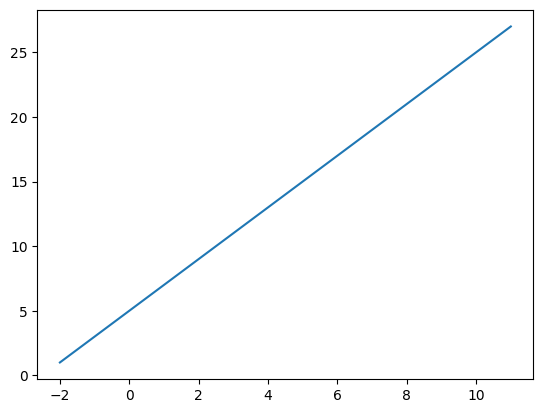

[-2 -1  0  1  2  3  4  5  6  7  8  9 10 11] 
 [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27]


In [109]:
import matplotlib.pyplot as plt

xs = np.arange(-2, 12, 1)
xs

def f (x):
  return 2*x + 5

def generate_examples(input_list):

   plt.plot(input_list, f(input_list))
   plt.show()
   return f(input_list)

print(xs, "\n", generate_examples(xs))

In [110]:
## our data in tensor form
x = torch.tensor([[-2.0], [-1.0], [3.0], [4.0], [6.0], [0.0]], dtype=torch.float)
y = torch.tensor([[1.0], [3.0], [11.0], [13.0], [17.0], [5.0]], dtype=torch.float)

In [111]:
x.shape, y.shape

(torch.Size([6, 1]), torch.Size([6, 1]))

In [112]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer = nn.Linear(1, 1, bias=True)

  def forward(self, x):
    return self.layer(x)

nn101 = NeuralNetwork()

#print the weights and bias of Linear Layer
print(list(nn101.parameters()))

[Parameter containing:
tensor([[-0.3101]], requires_grad=True), Parameter containing:
tensor([-0.9589], requires_grad=True)]


In [113]:
nn101

NeuralNetwork(
  (layer): Linear(in_features=1, out_features=1, bias=True)
)

In [114]:
import matplotlib.pyplot as plt

losses = []

## training
def train_model(model, x, y, epochs=150):

  ## loss function
  mse = nn.MSELoss()

  ## optimizer algorithm  (one alternative to SGD is Adam)
  optimizer = optim.SGD(model.parameters(), lr=0.01)

  for epoch in range(epochs):

      model.train() # signal that we are in training mode - should be added after each epoch

      # forward pass: compute predicted targets by passing inputs to the model
      output = model(x)

      # loss: compute loss according to the selected loss function
      loss = mse(output, y)

      # reset gradient (as we are not training a recurrent neural network)
      optimizer.zero_grad()

      # backward pass: compute gradient of the loss with respect to model parameters
      loss.backward()

      # call the step function on an Optimizer to make an update of weights and biases
      optimizer.step()

      # save loss value for later
      losses.append(loss.item())

      print('Epoch: %d | Loss: %.4f' %(epoch, loss.item()))

def show_loss(losses):
  # plotting the loss evolution during training
  plt.plot(losses)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training Loss')
  plt.show()

In [115]:
train_model(nn101, x, y)

Epoch: 0 | Loss: 140.0983
Epoch: 1 | Loss: 92.2816
Epoch: 2 | Loss: 63.3537
Epoch: 3 | Loss: 45.7660
Epoch: 4 | Loss: 34.9889
Epoch: 5 | Loss: 28.3046
Epoch: 6 | Loss: 24.0822
Epoch: 7 | Loss: 21.3432
Epoch: 8 | Loss: 19.5001
Epoch: 9 | Loss: 18.2003
Epoch: 10 | Loss: 17.2322
Epoch: 11 | Loss: 16.4684
Epoch: 12 | Loss: 15.8326
Epoch: 13 | Loss: 15.2788
Epoch: 14 | Loss: 14.7790
Epoch: 15 | Loss: 14.3166
Epoch: 16 | Loss: 13.8813
Epoch: 17 | Loss: 13.4668
Epoch: 18 | Loss: 13.0693
Epoch: 19 | Loss: 12.6863
Epoch: 20 | Loss: 12.3161
Epoch: 21 | Loss: 11.9577
Epoch: 22 | Loss: 11.6104
Epoch: 23 | Loss: 11.2735
Epoch: 24 | Loss: 10.9465
Epoch: 25 | Loss: 10.6292
Epoch: 26 | Loss: 10.3212
Epoch: 27 | Loss: 10.0221
Epoch: 28 | Loss: 9.7317
Epoch: 29 | Loss: 9.4498
Epoch: 30 | Loss: 9.1760
Epoch: 31 | Loss: 8.9102
Epoch: 32 | Loss: 8.6521
Epoch: 33 | Loss: 8.4014
Epoch: 34 | Loss: 8.1581
Epoch: 35 | Loss: 7.9217
Epoch: 36 | Loss: 7.6923
Epoch: 37 | Loss: 7.4694
Epoch: 38 | Loss: 7.2530
Epoch:

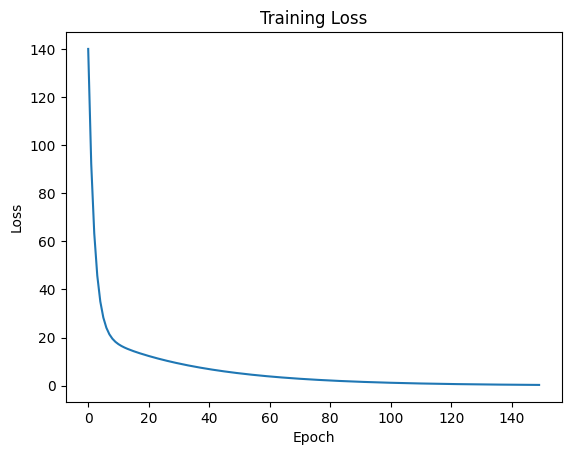

In [116]:
show_loss(losses)

In [117]:
def evaluate_model(model, test_value):

  model.eval() # say that the model is now in evaluation mode

  ## test the model
  sample = torch.tensor([test_value], dtype=torch.float) # 1.0 7.0 10.0
  predicted = model(sample)
  print("Original values: ", 2*test_value + 5)
  print("Predicted values: ", predicted.item())

evaluate_model(nn101, 10.0)

Original values:  25.0
Predicted values:  25.37367057800293


# Part 3: Cartesian to Polar Coordinates

## Initialize data

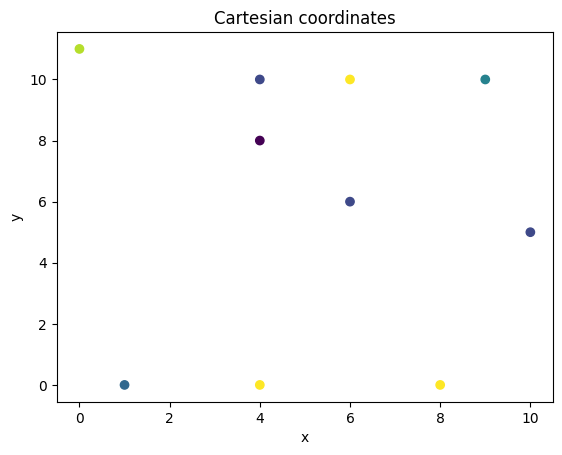

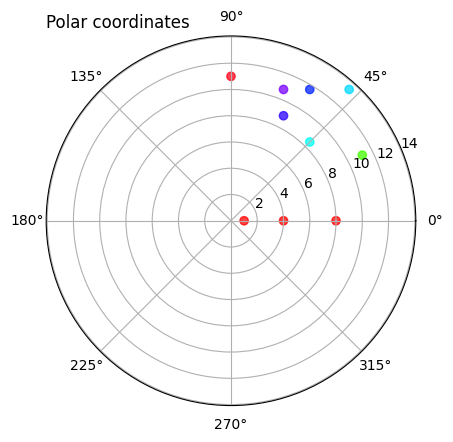

Cartersian coordinates (x, y):  tensor([[ 1.,  0.],
        [ 6.,  6.],
        [ 0., 11.],
        [ 9., 10.],
        [ 4., 10.],
        [ 4.,  8.],
        [ 8.,  0.],
        [10.,  5.],
        [ 4.,  0.],
        [ 6., 10.]])
Polar coordinates (r, theta):  tensor([[ 1.0000,  0.0000],
        [ 8.4853,  0.7854],
        [11.0000,  1.5708],
        [13.4536,  0.8380],
        [10.7703,  1.1903],
        [ 8.9443,  1.1071],
        [ 8.0000,  0.0000],
        [11.1803,  0.4636],
        [ 4.0000,  0.0000],
        [11.6619,  1.0304]])


[[1.0, 0.0],
 [8.485280990600586, 45.00000125223908],
 [11.0, 90.00000250447816],
 [13.45362377166748, 48.012787449847956],
 [10.770329475402832, 68.19859191912023],
 [8.9442720413208, 63.434951614575716],
 [8.0, 0.0],
 [11.180339813232422, 26.56505088990245],
 [4.0, 0.0],
 [11.661903381347656, 59.0362414871958]]

In [42]:
import random
import matplotlib.pyplot as plt
import numpy as np
import math


N = 10
c = np.random.randint(0, N, size=N)

x = []
y = []
for _ in range(N):
    x.append(random.randint(0, N+1))
    y.append(random.randint(0, N+1))

radius = [np.sqrt(x**2 + y**2) for x, y in zip(x, y)]
theta = [np.arctan2(y, x) for x, y in zip(x, y)]

u = [[a, b] for a, b in zip(x, y)]
X = torch.tensor(u, dtype=torch.float)

v = [[a, b] for a, b in zip(radius, theta)]
Y = torch.tensor(v, dtype=torch.float)

plt.scatter(x, y, c=c)
plt.title('Cartesian coordinates')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

colors = theta
plt.axes(projection='polar')
plt.scatter(theta, radius, c=colors, cmap='hsv', alpha=0.75)
plt.title('Polar coordinates', loc='left')
plt.show()

print("Cartersian coordinates (x, y): ", X)
print("Polar coordinates (r, theta): ", Y)

with_angles_in_degree = [[u[0].item(), math.degrees (u[1])] for u in Y]
with_angles_in_degree

In [43]:
len(x), len(y), len(radius), len(theta)

(10, 10, 10, 10)

In [44]:
X.shape

torch.Size([10, 2])

In [45]:
Y.shape

torch.Size([10, 2])

## Training

In [56]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()

    '''
    self.layer = nn.Linear(2, 2, bias=False)
    '''
    self.fc = nn.Sequential(
        nn.Linear(2, 100),
        nn.ReLU(),
        nn.Linear(100, 100),
        nn.ReLU(),
        nn.Linear(100, 2))


  def forward(self, x):
    #output = self.layer(x)
    output = self.fc(x)
    return output

nn102 = NeuralNetwork()

#print the weights and bias of Linear Layer
#print(list(nn102.parameters()))
nn102

NeuralNetwork(
  (fc): Sequential(
    (0): Linear(in_features=2, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=2, bias=True)
  )
)

In [57]:
import matplotlib.pyplot as plt


## training
def train_model(model, x, y, epochs=250):

  losses = []

  ## loss function
  mse = nn.MSELoss()

  ## optimizer algorithm
  optimizer = optim.SGD(model.parameters(), lr=0.001)

  for epoch in range(epochs):
      model.train() # signal that we are in training mode - should be added after each epoch

      # forward pass: compute predicted targets by passing inputs to the model
      output = model(x)

      # loss: compute loss according to the selected loss function
      loss = mse(output, y)

      # reset gradient (as we are not training a recurrent neural network)
      optimizer.zero_grad()

      # backward pass: compute gradient of the loss with respect to model parameters
      loss.backward()

      # call the step function on an Optimizer to make an update of weights and biases
      optimizer.step()

      # save loss value for later
      losses.append(loss.item())

      print('Epoch: %d | Loss: %.4f' %(epoch, loss.item()))

  show_loss(losses)

def show_loss(losses):
  # plotting the loss evolution during training
  plt.plot(losses)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training Loss')
  plt.show()

Epoch: 0 | Loss: 52.5107
Epoch: 1 | Loss: 36.8801
Epoch: 2 | Loss: 26.1185
Epoch: 3 | Loss: 17.2141
Epoch: 4 | Loss: 10.0203
Epoch: 5 | Loss: 5.0368
Epoch: 6 | Loss: 2.2697
Epoch: 7 | Loss: 1.0538
Epoch: 8 | Loss: 0.6112
Epoch: 9 | Loss: 0.4644
Epoch: 10 | Loss: 0.4127
Epoch: 11 | Loss: 0.3891
Epoch: 12 | Loss: 0.3739
Epoch: 13 | Loss: 0.3616
Epoch: 14 | Loss: 0.3505
Epoch: 15 | Loss: 0.3400
Epoch: 16 | Loss: 0.3301
Epoch: 17 | Loss: 0.3207
Epoch: 18 | Loss: 0.3116
Epoch: 19 | Loss: 0.3029
Epoch: 20 | Loss: 0.2946
Epoch: 21 | Loss: 0.2865
Epoch: 22 | Loss: 0.2788
Epoch: 23 | Loss: 0.2714
Epoch: 24 | Loss: 0.2642
Epoch: 25 | Loss: 0.2573
Epoch: 26 | Loss: 0.2506
Epoch: 27 | Loss: 0.2441
Epoch: 28 | Loss: 0.2379
Epoch: 29 | Loss: 0.2319
Epoch: 30 | Loss: 0.2261
Epoch: 31 | Loss: 0.2206
Epoch: 32 | Loss: 0.2152
Epoch: 33 | Loss: 0.2099
Epoch: 34 | Loss: 0.2049
Epoch: 35 | Loss: 0.1999
Epoch: 36 | Loss: 0.1952
Epoch: 37 | Loss: 0.1906
Epoch: 38 | Loss: 0.1861
Epoch: 39 | Loss: 0.1817
Epoch

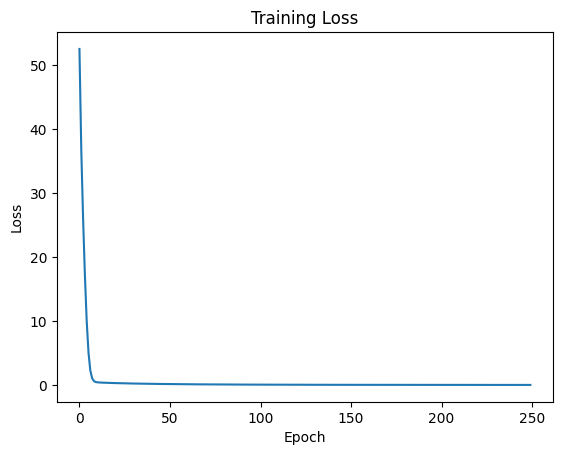

In [58]:
train_model(nn102, X, Y)

In [59]:
# evaluate the model using one example
def evaluate_model(model, test_value):

  model.eval() # model in evaluation mode, see https://stackoverflow.com/a/66843176

  ## test the model
  sample = torch.tensor([test_value], dtype=torch.float)
  predicted = model(sample)
  r = np.sqrt(test_value[0]**2 + test_value[1]**2)
  theta = np.arctan2(test_value[1], test_value[0])
  np.set_printoptions(legacy='1.25')

  print("Original values: ", [r, theta])
  print("Predicted values: ", predicted.tolist())

evaluate_model(nn102, [-10.0, 7.0] ) # [-9.0, 12.0] [-10.0, 7.0] [-1.0, 5.0]

Original values:  [12.206555615733702, 2.5308666892005847]
Predicted values:  [[7.989848613739014, 1.111101508140564]]


## Final Model

NeuralNetwork(
  (fc): Sequential(
    (0): Linear(in_features=2, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=2, bias=True)
  )
)
Epoch 1/200, Loss: 231.3845
Epoch 10/200, Loss: 7.5305
Epoch 20/200, Loss: 6.5096
Epoch 30/200, Loss: 6.0230
Epoch 40/200, Loss: 5.5989
Epoch 50/200, Loss: 5.2591
Epoch 60/200, Loss: 5.0691
Epoch 70/200, Loss: 4.7817
Epoch 80/200, Loss: 4.5297
Epoch 90/200, Loss: 4.4203
Epoch 100/200, Loss: 4.1745
Epoch 110/200, Loss: 3.9790
Epoch 120/200, Loss: 3.8732
Epoch 130/200, Loss: 3.6823
Epoch 140/200, Loss: 3.4771
Epoch 150/200, Loss: 3.4201
Epoch 160/200, Loss: 3.2412
Epoch 170/200, Loss: 3.1072
Epoch 180/200, Loss: 2.9790
Epoch 190/200, Loss: 2.8556
Epoch 200/200, Loss: 2.7366


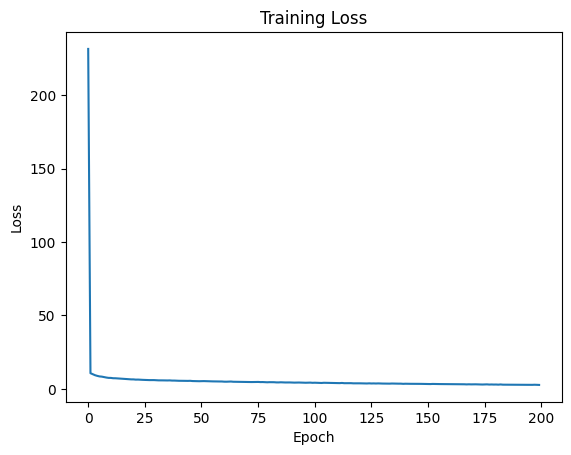

In [73]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Dataset: generate random (x, y) and compute (r, theta)
def generate_data(num_samples=1000):
    x = np.random.uniform(-20, 20, num_samples)
    y = np.random.uniform(-20, 20, num_samples)
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    inputs = np.stack((x, y), axis=1).astype(np.float32)
    targets = np.stack((r, theta), axis=1).astype(np.float32)
    return torch.from_numpy(inputs), torch.from_numpy(targets)

# Define the model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(2, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 2))

    def forward(self, x):
        return self.fc(x)

# MAPE loss function
def mape(output, target):
    return torch.mean(torch.abs((target - output) / target))

def show_loss(losses):
  # plotting the loss evolution during training
  plt.plot(losses)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training Loss')
  plt.show()

# Training function
def train_model(model, inputs, targets, epochs=200, batch_size=64):

    losses = []

    dataset = torch.utils.data.TensorDataset(inputs, targets) # https://docs.pytorch.org/docs/stable/data.html
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # print the model
    print(model)

    # loss function
    mse = nn.MSELoss()

    # optimizer algorithm
    optimizer = optim.SGD(model.parameters(), lr=0.001)


    for epoch in range(epochs):

        model.train() # signal that we are in training mode - should be added after each epoch
        total_loss = 0.0

        for batch_inputs, batch_targets in dataloader:
            optimizer.zero_grad() # clear the gradients of all optimized tensors

            # forward pass: compute predicted targets by passing inputs to the model
            outputs = model(batch_inputs)

            # loss: compute loss according to the selected loss function
            loss = mse(outputs, batch_targets)

            # backward pass: compute gradient of the loss with respect to model parameters
            loss.backward()

            # call the step function on an Optimizer to make an update of weights and biases
            optimizer.step()

            total_loss += loss.item()

        # save loss values for plotting
        losses.append(total_loss)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

    show_loss(losses)
    path = "my_torch_model16052025.pt"
    torch.save(model.state_dict(), path)

# Generate data
inputs, targets = generate_data()

# Train the model
model = NeuralNetwork()
train_model(model, inputs, targets)

In [74]:
inputs.shape, targets.shape

(torch.Size([1000, 2]), torch.Size([1000, 2]))

In [75]:
inputs

tensor([[  1.9054,  18.6169],
        [ -9.4396, -15.3485],
        [ -0.4954, -12.8245],
        ...,
        [ 18.1721, -18.8538],
        [  4.8148,  -6.8568],
        [ -7.5446,  15.7323]])

In [76]:
targets

tensor([[18.7142,  1.4688],
        [18.0189, -2.1222],
        [12.8340, -1.6094],
        ...,
        [26.1857, -0.8038],
        [ 8.3785, -0.9586],
        [17.4479,  2.0180]])

In [77]:
# evaluate the model using one example
def evaluate_model(model, test_value):

  model.eval() # model in evaluation mode, see https://stackoverflow.com/a/66843176

  ## test the model
  sample = torch.tensor([test_value], dtype=torch.float)
  predicted = model(sample)
  r = np.sqrt(test_value[0]**2 + test_value[1]**2)
  theta = np.arctan2(test_value[1], test_value[0])
  np.set_printoptions(legacy='1.25')

  print("Original values: ", [r, theta])
  print("Predicted values: ", predicted.tolist())

evaluate_model(model, [-1.0, 5.0]) # [-9.0, 12.0] [-10.0, 7.0] [-1.0, 5.0]

Original values:  [5.0990195135927845, 1.7681918866447774]
Predicted values:  [[5.134925365447998, 0.9976102113723755]]


Mean r error: 0.0477
Mean θ error (rad): 0.3447


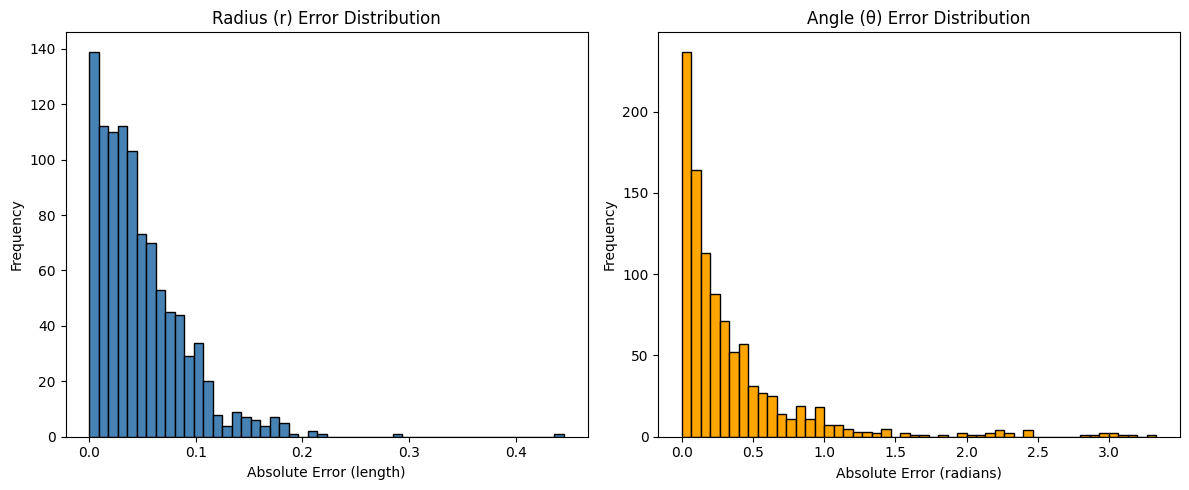

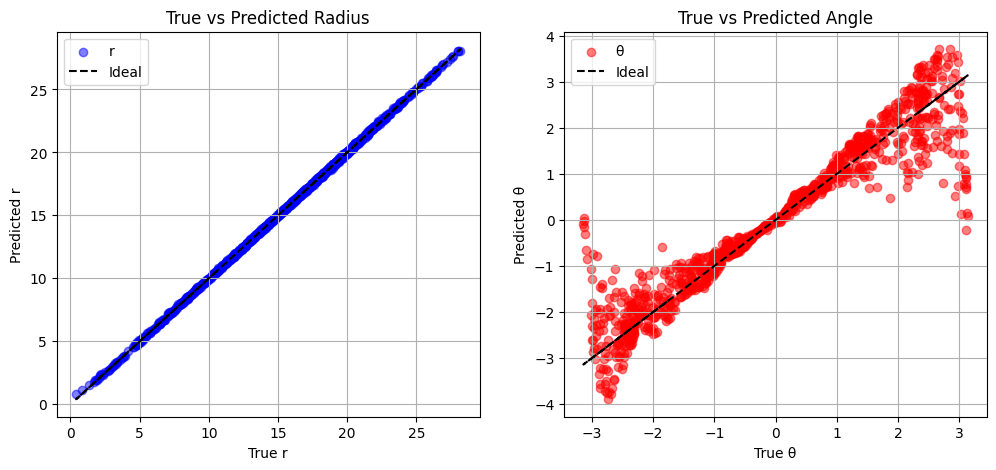

In [78]:
# evaluate the model using new examples
def evaluate_model(model, num_samples=1000):

    # generate new unseen data
    x, y = np.random.uniform(-20, 20, num_samples), np.random.uniform(-20, 20, num_samples)

    true_radius = np.sqrt(x**2 + y**2)
    true_theta = np.arctan2(y, x)

    input_coordinates = torch.from_numpy(np.stack((x, y), axis=1).astype(np.float32))
    output = model(input_coordinates)

    pred_radius, pred_theta =  output[:, 0], output[:, 1]

    #pred_radius = pred_radius.detach().numpy() (can be used as an alternative to torch_no.grad())
    #pred_theta = pred_theta.detach().numpy()

    with torch.no_grad():
      pred_radius = pred_radius.numpy()
      pred_theta = pred_theta.numpy()

    # compute (mean) errors
    r_error = np.abs(pred_radius - true_radius)
    theta_error = np.abs(pred_theta - true_theta)

    print(f"Mean r error: {np.mean(r_error):.4f}")
    print(f"Mean θ error (rad): {np.mean(theta_error):.4f}")

    # error histograms
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(r_error, bins=50, color='steelblue', edgecolor='black')
    plt.title('Radius (r) Error Distribution')
    plt.xlabel('Absolute Error (length)')
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    plt.hist(theta_error, bins=50, color='orange', edgecolor='black')
    plt.title('Angle (θ) Error Distribution')
    plt.xlabel('Absolute Error (radians)')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    # scatter plot of true vs predicted
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)

    plt.scatter(true_radius, pred_radius, alpha=0.5, label='r', c='blue')
    plt.xlabel("True r")
    plt.ylabel("Predicted r")
    plt.plot(true_radius, true_radius, 'k--', label="Ideal")
    plt.legend()
    plt.title("True vs Predicted Radius")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.scatter(true_theta, pred_theta, alpha=0.5, label='θ', c='red')
    plt.xlabel("True θ")
    plt.ylabel("Predicted θ")
    plt.plot(true_theta, true_theta, 'k--', label="Ideal")
    plt.legend()
    plt.title("True vs Predicted Angle")
    plt.grid(True)
    plt.show()

evaluate_model(model)

# Part 4: Saving and reusing a trained model

Saving

In [79]:
path = "my_torch_model_04052026.pt"
torch.save(model.state_dict(), path)

Reusing

In [80]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [82]:
checkpoint_path = "my_torch_model_04052026.pt"

# Define the model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        '''
        self.fc = nn.Sequential(
            nn.Linear(2, 100),
            nn.ReLU(),
            nn.Linear(100, 50),
            nn.ReLU(),
            nn.Linear(50, 2))
        '''

        self.fc = nn.Sequential(
            nn.Linear(2, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 2))

    def forward(self, x):
        return self.fc(x)

trained_model = NeuralNetwork()
# load the weights of the trained model
checkpoint = torch.load(checkpoint_path, weights_only=True)
trained_model.load_state_dict(checkpoint)

<All keys matched successfully>

Mean r error: 0.3605
Mean θ error (rad): 0.7128


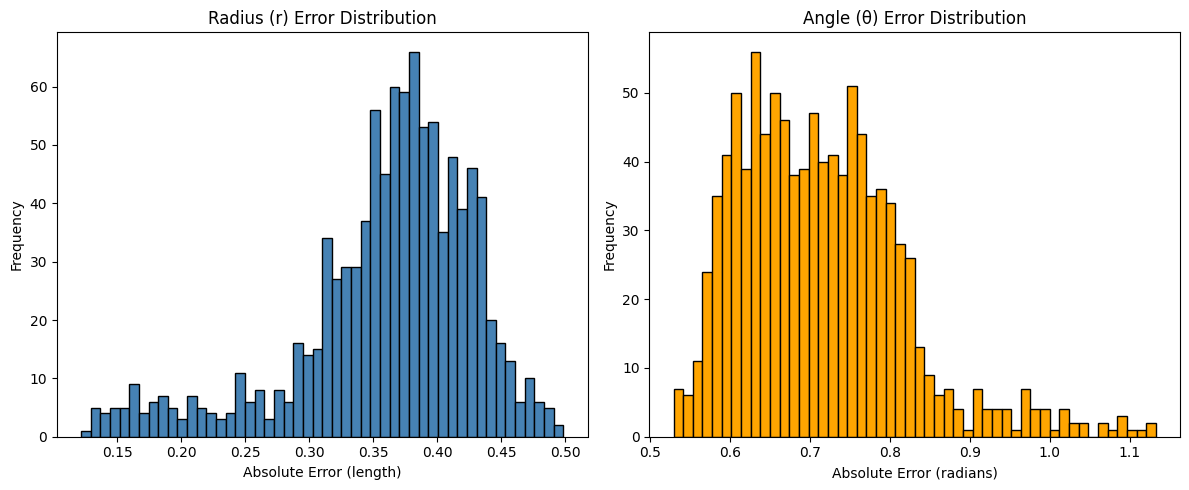

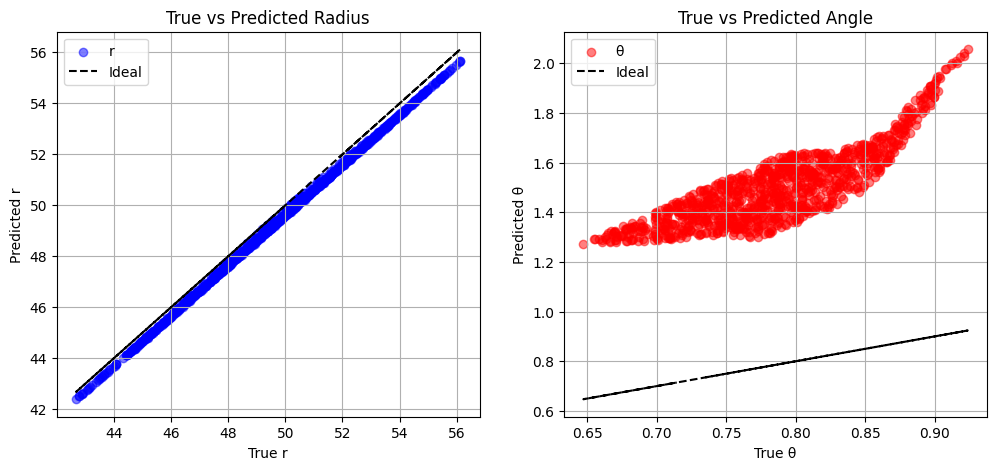

In [84]:
# evaluate the model using new examples
def evaluate_model(model, num_samples=1000):

    # generate new unseen data
    #x, y =  np.random.uniform(-20, 20, num_samples), np.random.uniform(-20, 20, num_samples)
    x, y =  np.random.uniform(30, 40, num_samples), np.random.uniform(30, 40, num_samples) # to illustrate training-test-data mismatch


    true_radius = np.sqrt(x**2 + y**2)
    true_theta = np.arctan2(y, x)

    input_coordinates = torch.from_numpy(np.stack((x, y), axis=1).astype(np.float32))
    output = model(input_coordinates)

    pred_radius, pred_theta =  output[:, 0], output[:, 1]

    #pred_radius = pred_radius.detach().numpy() (can be used as an alternative to torch_no.grad())
    #pred_theta = pred_theta.detach().numpy()

    with torch.no_grad():
      pred_radius = pred_radius.numpy()
      pred_theta = pred_theta.numpy()

    # compute (mean) errors
    r_error = np.abs(pred_radius - true_radius)
    theta_error = np.abs(pred_theta - true_theta)

    print(f"Mean r error: {np.mean(r_error):.4f}")
    print(f"Mean θ error (rad): {np.mean(theta_error):.4f}")

    # error histograms
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(r_error, bins=50, color='steelblue', edgecolor='black')
    plt.title('Radius (r) Error Distribution')
    plt.xlabel('Absolute Error (length)')
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    plt.hist(theta_error, bins=50, color='orange', edgecolor='black')
    plt.title('Angle (θ) Error Distribution')
    plt.xlabel('Absolute Error (radians)')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    # scatter plot of true vs predicted
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)

    plt.scatter(true_radius, pred_radius, alpha=0.5, label='r', c='blue')
    plt.xlabel("True r")
    plt.ylabel("Predicted r")
    plt.plot(true_radius, true_radius, 'k--', label="Ideal")
    plt.legend()
    plt.title("True vs Predicted Radius")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.scatter(true_theta, pred_theta, alpha=0.5, label='θ', c='red')
    plt.xlabel("True θ")
    plt.ylabel("Predicted θ")
    plt.plot(true_theta, true_theta, 'k--', label="Ideal")
    plt.legend()
    plt.title("True vs Predicted Angle")
    plt.grid(True)
    plt.show()

evaluate_model(trained_model)

# Project Work

* Exercice 01: use the function below to generate some data, and train a neural network that predicts the two classes from the spiral data (see below). A few tipps

  *   Use nn.BCEWithLogitsLoss() as loss criterion (It is[ more stable than](https://github.com/pytorch/pytorch/issues/39435#issuecomment-639386421)  BCELoss()),
  *  Where SGD as optimizer fails, Adam may still be successful
  *  Where some learning rates fail, others may still help you converge
  *  Because you are classifying a binary dataset, you will need sigmoid to convert logits to probabilities at some point in the process
  * The following [picture](https://cs231n.github.io/assets/nn3/learningrates.jpeg) and [picture](https://cs231n.github.io/assets/nn3/accuracies.jpeg) give you rough indication about how well the training process is going. For details, see the comments available [here](https://cs231n.github.io/neural-networks-3/#gradcheck)

* Exercice 02: Think about at least two examples, were predictive machine learning could be useful as a component in your own scenario

The notebook is to get started with the basics only (e.g. important notions such as regularization and weight decay are not introduced).

Happy coding!

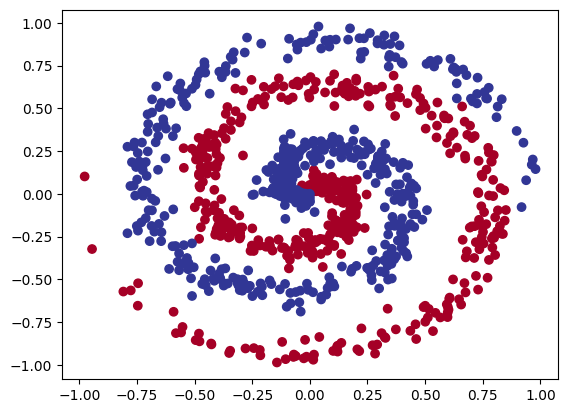

In [85]:
# Generate binary spiral data
def generate_spiral_data(points_per_class=500):
    X = np.zeros((points_per_class * 2, 2), dtype=np.float32)
    y = np.zeros(points_per_class * 2, dtype=np.float32)
    for j in range(2):
        ix = range(points_per_class * j, points_per_class * (j + 1))
        r = np.linspace(0.0, 1, points_per_class)
        t = np.linspace(j * 4, (j + 1) * 4, points_per_class) + np.random.randn(points_per_class) * 0.2
        X[ix] = np.c_[r * np.sin(t * 2.5), r * np.cos(t * 2.5)]
        y[ix] = j
    plt.scatter(X[:, 0], X[:, 1], c = y, cmap=plt.cm.RdYlBu) # for alternative color palettes, see https://matplotlib.org/stable/users/explain/colors/colormaps.html#qualitative
    plt.show()
    return torch.from_numpy(X), torch.from_numpy(y)

inputs, targets = generate_spiral_data()